# Self-Driving Car Engineer Nanodegree

## Deep Learning

## Project: Build a Traffic Sign Recognition Classifier

In this notebook, a template is provided for you to implement your functionality in stages, which is required to successfully complete this project. If additional code is required that cannot be included in the notebook, be sure that the Python code is successfully imported and included in your submission if necessary. 

> **Note**: Once you have completed all of the code implementations, you need to finalize your work by exporting the iPython Notebook as an HTML document. Before exporting the notebook to html, all of the code cells need to have been run so that reviewers can see the final implementation and output. You can then export the notebook by using the menu above and navigating to  \n",
    "**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission. 

In addition to implementing code, there is a writeup to complete. The writeup should be completed in a separate file, which can be either a markdown file or a pdf document. There is a [write up template](https://github.com/udacity/CarND-Traffic-Sign-Classifier-Project/blob/master/writeup_template.md) that can be used to guide the writing process. Completing the code template and writeup template will cover all of the [rubric points](https://review.udacity.com/#!/rubrics/481/view) for this project.

The [rubric](https://review.udacity.com/#!/rubrics/481/view) contains "Stand Out Suggestions" for enhancing the project beyond the minimum requirements. The stand out suggestions are optional. If you decide to pursue the "stand out suggestions", you can include the code in this Ipython notebook and also discuss the results in the writeup file.


>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

In [2]:
pip install tensorflow keras scikit-learn matplotlib pandas pillow opencv-python


  Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl.metadata (4.1 kB)
Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl (375.9 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\gayat\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
python.exe -m pip install --upgrade pip


SyntaxError: invalid syntax (1104305986.py, line 1)

---
## Step 0: Load The Data

In [50]:
# Load pickled data
import os
from PIL import Image # or use cv2 if available
import numpy as np

def load_kaggle_traffic_signs(dataset_dir, image_size=(32, 32)):
    data = []
    labels = []
    class_folders = sorted(os.listdir(dataset_dir))
    for label, class_folder in enumerate(class_folders):
        class_path = os.path.join(dataset_dir, class_folder)
        for image_name in os.listdir(class_path):
            img_path = os.path.join(class_path, image_name)
            try:
                img = Image.open(img_path).resize(image_size)
                data.append(np.array(img))
                labels.append(label)
            except:
                pass # skip corrupted images
    return np.array(data), np.array(labels)

def load_images_with_label_in_filename(data_dir, image_size=(32, 32)):
    data = []
    labels = []
    for image_name in os.listdir(data_dir):
        img_path = os.path.join(data_dir, image_name)
        try:
            label_str = image_name.split('_')[0]   # Extracts '000' from '000_0001_j.png'
            label = int(label_str)
            img = Image.open(img_path).resize(image_size)
            data.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    return np.array(data), np.array(labels)

# Example usage:
X_train, y_train = load_kaggle_traffic_signs('archive/traffic_Data/DATA/')
X_test, y_test = load_images_with_label_in_filename('archive/traffic_Data/TEST/')


---

## Step 1: Dataset Summary & Exploration

The pickled data is a dictionary with 4 key/value pairs:

- `'features'` is a 4D array containing raw pixel data of the traffic sign images, (num examples, width, height, channels).
- `'labels'` is a 1D array containing the label/class id of the traffic sign. The file `signnames.csv` contains id -> name mappings for each id.
- `'sizes'` is a list containing tuples, (width, height) representing the original width and height the image.
- `'coords'` is a list containing tuples, (x1, y1, x2, y2) representing coordinates of a bounding box around the sign in the image. **THESE COORDINATES ASSUME THE ORIGINAL IMAGE. THE PICKLED DATA CONTAINS RESIZED VERSIONS (32 by 32) OF THESE IMAGES**

Complete the basic data summary below. Use python, numpy and/or pandas methods to calculate the data summary rather than hard coding the results. For example, the [pandas shape method](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.shape.html) might be useful for calculating some of the summary results. 

### Provide a Basic Summary of the Data Set Using Python, Numpy and/or Pandas

In [7]:
from sklearn.model_selection import train_test_split

# 20% of training data will be reserved for validation set
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2,         # 20% goes to validation, 80% stays as new train set
    random_state=42,       # for reproducibility (optional)
    stratify=y_train       # preserves class distribution (recommended for classification)
)

# TODO: Number of training examples
n_train = len(X_train_new)

# TODO: Number of validation examples
n_validation = len(X_val)

# TODO: Number of testing examples.
n_test = len(X_test)

# TODO: What's the shape of an traffic sign image?
image_shape = format(X_train_new.shape)

image_size=X_train_new.shape[1]

print(X_train_new.shape)


# TODO: How many unique classes/labels there are in the dataset.
n_classes = 43

print("Number of training examples =", n_train)
print('Number of validation examples:', n_validation)
print("Number of testing examples =", n_test)
print("Image data shape =", image_shape)
print("Image data size =", image_size)
print("Number of classes =", n_classes)

(3336, 32, 32, 3)
Number of training examples = 3336
Number of validation examples: 834
Number of testing examples = 1994
Image data shape = (3336, 32, 32, 3)
Image data size = 32
Number of classes = 43


### Include an exploratory visualization of the dataset

Visualize the German Traffic Signs Dataset using the pickled file(s). This is open ended, suggestions include: plotting traffic sign images, plotting the count of each sign, etc. 

The [Matplotlib](http://matplotlib.org/) [examples](http://matplotlib.org/examples/index.html) and [gallery](http://matplotlib.org/gallery.html) pages are a great resource for doing visualizations in Python.

**NOTE:** It's recommended you start with something simple first. If you wish to do more, come back to it after you've completed the rest of the sections. It can be interesting to look at the distribution of classes in the training, validation and test set. Is the distribution the same? Are there more examples of some classes than others?

# Summary of dataset
* Available dataset consists of 34799 training examples
* 4410 validation examples
* 12630 testing examples

Below a sample image belonging to each class from training set is plotted to get an idea of how the images from training set look like.
Also, number of examples for each class is printed below.
Each class has at least 180 images

[94, 32, 56, 110, 77, 29, 102, 18, 114, 104, 6, 3, 64, 14, 10, 14, 11, 80, 2, 101, 22, 357, 35, 208, 120, 34, 11, 3, 21, 125, 32, 46, 24, 27, 78, 26, 14, 26, 66, 24, 19, 14, 10]


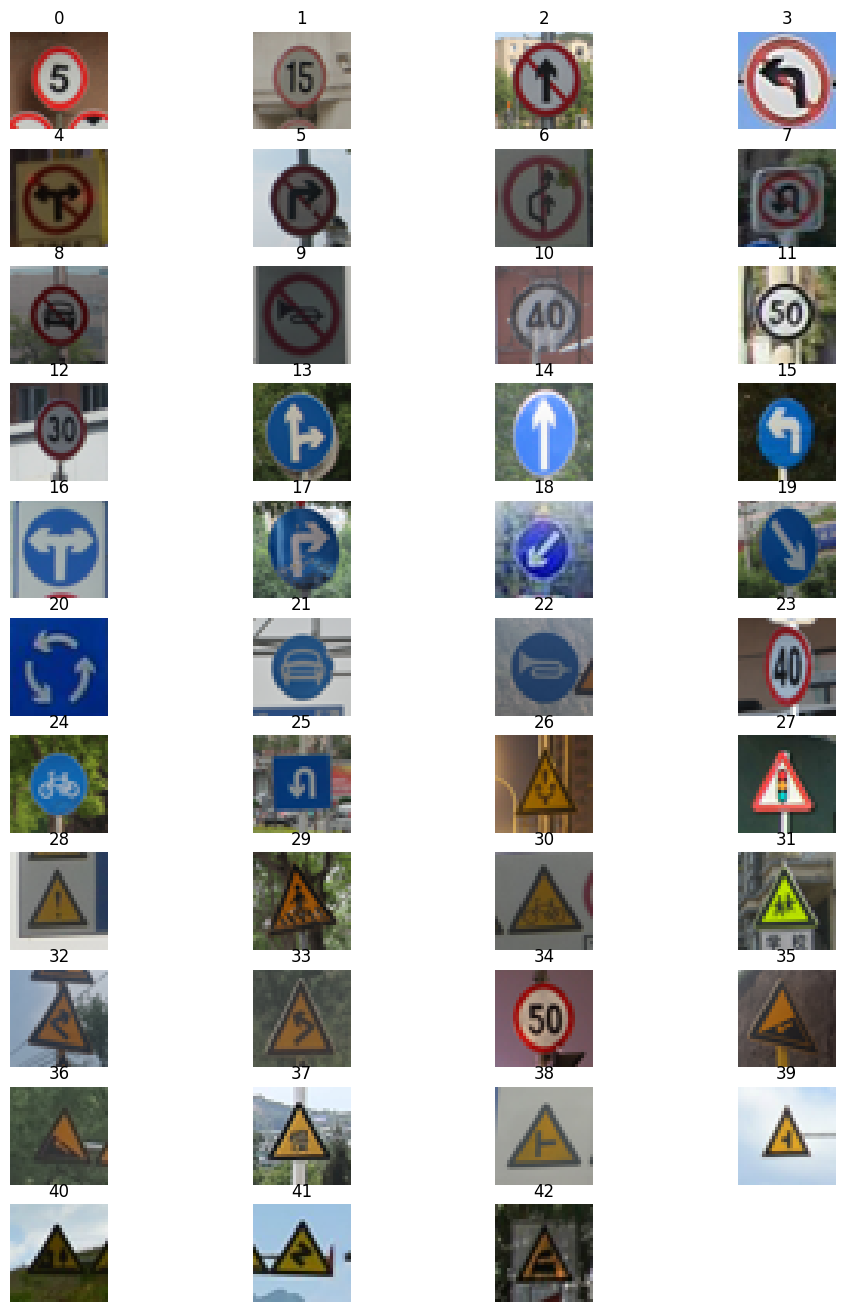

In [9]:
### Data exploration visualization code goes here.
### Feel free to use as many code cells as needed.
import random
import matplotlib.pyplot as plt
# Visualizations will be shown in the notebook.
%matplotlib inline


num_of_samples=[]
plt.figure(figsize=(12, 16.5))
for i in range(0, n_classes):
    plt.subplot(11, 4, i+1)
    x_selected = X_train_new[y_train_new == i]
    plt.imshow(x_selected[0, :, :, :]) #draw the first image of each class
    plt.title(i)
    plt.axis('off')
    num_of_samples.append(len(x_selected))
print(num_of_samples)
plt.show()

In [11]:
from sklearn.utils import shuffle

X_train_new, y_train_new = shuffle(X_train_new, y_train_new)

In [12]:
import tensorflow as tf

EPOCHS = 15
BATCH_SIZE = 128

###### ----

## Step 2: Design and Test a Model Architecture

Design and implement a deep learning model that learns to recognize traffic signs. Train and test your model on the [German Traffic Sign Dataset](http://benchmark.ini.rub.de/?section=gtsrb&subsection=dataset).

The LeNet-5 implementation shown in the [classroom](https://classroom.udacity.com/nanodegrees/nd013/parts/fbf77062-5703-404e-b60c-95b78b2f3f9e/modules/6df7ae49-c61c-4bb2-a23e-6527e69209ec/lessons/601ae704-1035-4287-8b11-e2c2716217ad/concepts/d4aca031-508f-4e0b-b493-e7b706120f81) at the end of the CNN lesson is a solid starting point. You'll have to change the number of classes and possibly the preprocessing, but aside from that it's plug and play! 

With the LeNet-5 solution from the lecture, you should expect a validation set accuracy of about 0.89. To meet specifications, the validation set accuracy will need to be at least 0.93. It is possible to get an even higher accuracy, but 0.93 is the minimum for a successful project submission. 

There are various aspects to consider when thinking about this problem:

- Neural network architecture (is the network over or underfitting?)
- Play around preprocessing techniques (normalization, rgb to grayscale, etc)
- Number of examples per label (some have more than others).
- Generate fake data.

Here is an example of a [published baseline model on this problem](http://yann.lecun.com/exdb/publis/pdf/sermanet-ijcnn-11.pdf). It's not required to be familiar with the approach used in the paper but, it's good practice to try to read papers like these.

### Pre-process the Data Set (normalization, grayscale, etc.)

Minimally, the image data should be normalized so that the data has mean zero and equal variance. For image data, `(pixel - 128)/ 128` is a quick way to approximately normalize the data and can be used in this project. 

Other pre-processing steps are optional. You can try different techniques to see if it improves performance. 

Use the code cell (or multiple code cells, if necessary) to implement the first step of your project.

# Preprocessing and data augmentation

### Preprocessing
For training the model, following techniques were used:
* Grayscaling the images
* Normalization of gray scaled images
The above 2 techniques alone proved sufficient as far as preprocessing is concerned to bring the validation accuracy to about 96%.

### Data augmentation
    In addition, training dataset was augmented in order to expand the dataset to cover real world scenarios. Only  rotation of training images 4 times each with varying angles was used to augment the training data. Shearing and translation using skimage transform module was applied to bring more variation to the training images. However, shearing and translation did not bring about any significant positive impact to validation accuracy. In fact, with shearing and translation enabled, there was a slight drop in final validation accuracy of about 1-2% and also training accuracy started lagging behind validation accuracy by about 20-25%.
    Hence I decided to disable shearing and translation and stick to only rotation of images for augmentation. Final count of training images came upto 173995 after augmentation.
    
    So the least number of examples for a particular class which was earlier 180 would now be about 900 after augmentation.


In [14]:
pip install scikit-image

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.8 MB 2.2 MB/s eta 0:00:06
   -- ------------------------------------- 0.7/12.8 MB 7.8 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.8 MB 17.1 MB/s eta 0:00:01
   --------------- ------------------------ 4.9/12.8 MB 25.8 MB/s eta 0:00:01
   ----------------------- ---------------- 7.5/12.8 MB 31.7 MB/s eta 0:00:01
   -------------------------------- ------- 10.3/12.8 MB 38.6 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.8 MB 50.4 MB/s eta 0:00:01
   ---------------------------------------  12.8/12.8 MB 50.4 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 38.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/315.8 kB ? eta -:--:--
   ---------------------------------------- 315.8/315.8 kB 9.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\gayat\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
### Preprocess the data here. It is required to normalize the data. Other preprocessing steps could include 
### converting to grayscale, etc.
### Feel free to use as many code cells as needed.

#importing some useful packages
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import io
from skimage import transform as trans

def augment_data(x_train_data, angle, shear):
    ang_rot = np.random.uniform(angle)-angle/2
    rows,cols,ch = x_train_data.shape
    Rot_M = cv2.getRotationMatrix2D((cols/2,rows/2),ang_rot,1)   
    
    pts1 = np.float32([[5,5],[20,5],[5,20]])

    pt1 = 5+shear*np.random.uniform()-shear/2
    pt2 = 20+shear*np.random.uniform()-shear/2

    pts2 = np.float32([[pt1,5],[pt2,pt1],[5,pt2]])
    #T = cv2.getAffineTransform(pts1,pts2)

    x_train_data_rot = cv2.warpAffine(x_train_data,Rot_M,(cols,rows))
    #x_train_data_shear = cv2.warpAffine(x_train_data,T,(cols,rows))
    
    #Create Afine transform
    #afine_trans = trans.AffineTransform(translation=(np.random.uniform(-3, 3),np.random.uniform(-3, 3)))

    # Apply transform to image data
    #x_train_data_rot = trans.warp(x_train_data_rot, inverse_map=afine_trans)
    return x_train_data_rot

def gray_image(img):
    img = img.astype(np.float32)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray.reshape(32, 32, 1)
    return gray

        

(32, 32, 3)


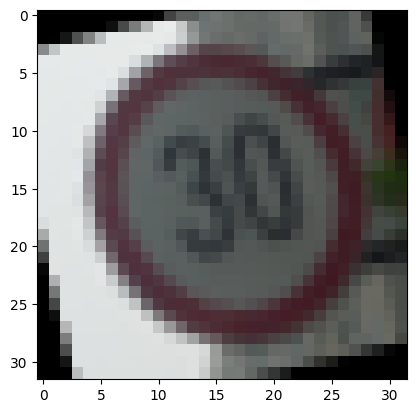

In [16]:
#Test preprocess functions
img = augment_data(X_train_new[1610], 30, 10)
plt.imshow(img)
#plt.imshow(X_train[1010])
print(img.shape)

Augmenting data
16680
(16680, 32, 32, 3)
(16680, 32, 32, 1)


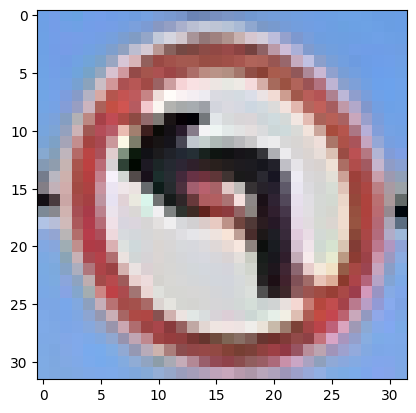

In [27]:
#Augment data

samples = 4
x_shape = X_train_new.shape
y_shape = y_train_new.shape
X_train_augmented = []
y_train_augmented = []
idx = 0
print("Augmenting data")
for (img, label) in zip(X_train_new, y_train_new):
    idx += 1
    tmp_x = [img]
    tmp_y = [label]
    for i in range(0,samples):
        img = augment_data(img, 30, 10)        
        tmp_x.append(img)
        tmp_y.append(label)
    X_train_augmented.append(tmp_x)
    y_train_augmented.append(tmp_y)

X_train_augmented = np.array(X_train_augmented,dtype = np.float32()).reshape([len(X_train_new)*(samples+1), 32, 32, 3])
y_train_augmented = np.array(y_train_augmented,dtype = np.int32()).reshape(len(y_train_new)*(samples+1),)
n_train_augmented = len(X_train_augmented)
#n_validation_augmented = len(y_train_augmented)

print(n_train_augmented)

#Grayscale the training data
print(X_train_augmented.shape)

X_train_gray = np.zeros((n_train_augmented, 32, 32, 1), dtype=np.float32)

for i, element in enumerate(X_train_augmented):
    X_train_gray[i] = gray_image(element)

#Grayscale the validation data
X_valid_gray = np.zeros((n_validation, 32, 32, 1), dtype=np.float32)
for i, element in enumerate(X_val):
    X_valid_gray[i] = gray_image(element)

#plt.imshow(X_train[2])
print(X_train_gray.shape)
X_train_gray = (X_train_gray/255)
X_valid_gray = (X_valid_gray/255)

plt.imshow(X_train_augmented[2000].squeeze() / 255.0, cmap='gray')

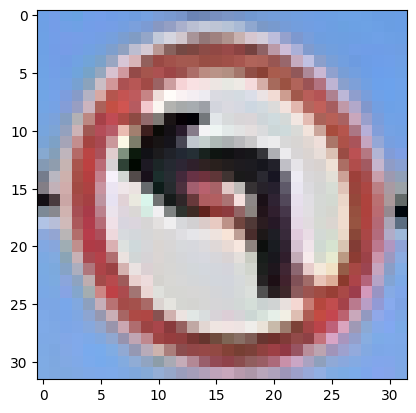

In [28]:
#np.asarray(X_train_gray[2003].shape[2])
#print(X_train_gray[2003].shape)
plt.imshow(X_train_augmented[2000].squeeze() / 255.0, cmap='gray')
#print(X_train_gray[2002].shape)

### Model Architecture

In [47]:
### Define your architecture here.
### Feel free to use as many code cells as needed.
from tensorflow.keras.layers import Flatten
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout


def LeNet(input_shape=(32, 32, 1), num_classes=58):
    inputs = Input(shape=input_shape)
    
    # Layer 1: Convolutional
    x = Conv2D(6, (5, 5), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)
    
    # Layer 2: Convolutional
    x = Conv2D(16, (5, 5), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Flatten and fully connected layers
    x = Flatten()(x)
    x = Dense(120, activation='relu')(x)
    x = Dropout(0.5)(x)  # Dropout: automatically handles training/inference (equivalent to keep_prob=0.5)
    x = Dense(84, activation='relu')(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)
    
# def LeNet(x, keep_prob):    
#     # Arguments used for tf.truncated_normal, randomly defines variables for the weights and biases for each layer
#     mu = 0
#     sigma = 0.1
    
    # SOLUTION: Layer 1: Convolutional. Input = 32x32x1. Output = 28x28x6.
    # conv1_W = tf.Variable(tf.truncated_normal(shape=(5, 5, 1, 6), mean = mu, stddev = sigma))
    # conv1_b = tf.Variable(tf.zeros(6))
    # conv1   = tf.nn.conv2d(x, conv1_W, strides=[1, 1, 1, 1], padding='VALID') + conv1_b 
    
    # # SOLUTION: Activation.
    # conv1 = tf.nn.relu(conv1)
    
    
    # # SOLUTION: Pooling. Input = 28x28x6. Output = 14x14x6.
    # conv1 = tf.nn.max_pool(conv1, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')
    
    # conv1 = tf.nn.dropout(conv1, keep_prob)
    
    # # SOLUTION: Layer 2: Convolutional. Output = 10x10x16.
    # conv2_W = tf.Variable(tf.truncated_normal(shape=(5, 5, 6, 16), mean = mu, stddev = sigma))
    # conv2_b = tf.Variable(tf.zeros(16))
    # conv2   = tf.nn.conv2d(conv1, conv2_W, strides=[1, 1, 1, 1], padding='VALID') + conv2_b
    
    # # SOLUTION: Activation.
    # conv2 = tf.nn.relu(conv2)

    # # SOLUTION: Pooling. Input = 10x10x16. Output = 5x5x16.
    # conv2 = tf.nn.max_pool(conv2, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')
    
    # #conv2 = tf.nn.dropout(conv2, keep_prob)

    # # SOLUTION: Flatten. Input = 5x5x16. Output = 400.
    # fc0   = Flatten(conv2)
    
    # # SOLUTION: Layer 3: Fully Connected. Input = 400. Output = 120.
    # fc1_W = tf.Variable(tf.truncated_normal(shape=(400, 120), mean = mu, stddev = sigma))
    # fc1_b = tf.Variable(tf.zeros(120))
    # fc1   = tf.matmul(fc0, fc1_W) + fc1_b
    
    # # SOLUTION: Activation.
    # fc1    = tf.nn.relu(fc1)
    
    # fc1 = tf.nn.dropout(fc1, keep_prob)

    # # SOLUTION: Layer 4: Fully Connected. Input = 120. Output = 84.
    # fc2_W  = tf.Variable(tf.truncated_normal(shape=(120, 84), mean = mu, stddev = sigma))
    # fc2_b  = tf.Variable(tf.zeros(84))
    # fc2    = tf.matmul(fc1, fc2_W) + fc2_b
    
    # # SOLUTION: Activation.
    # fc2    = tf.nn.relu(fc2)
    
    # fc2_drop = tf.nn.dropout(fc2, keep_prob)
    
    # # SOLUTION: Layer 5: Fully Connected. Input = 84. Output = 43.
    # fc3_W  = tf.Variable(tf.truncated_normal(shape=(84, 43), mean = mu, stddev = sigma))
    # fc3_b  = tf.Variable(tf.zeros(43))
    # logits = tf.matmul(fc2_drop, fc3_W) + fc3_b
    
    # return logits

In [36]:
x = tf.placeholder(tf.float32, (None, 32, 32, 1))
y = tf.placeholder(tf.int32, (None))
keep_prob = tf.placeholder(tf.float32)
one_hot_y = tf.one_hot(y, 43)

AttributeError: module 'tensorflow' has no attribute 'placeholder'

# Model architecture
More or less, the same architecture(LeNet) is retained as the one introduced in LeNet lab. Since all the images are onverted to gray scale, the model accepts input images of 32x32x1 and the final layer output of 43 which is equal to the number of distinct classes. The model consists of 5 layers - 2 convolution layers and 3 fully onnected layers. 
     * Regularization technique of dropout is introduced between the layers of network.
     * Input to layer 1 is 32x32x1 and output is 28x28x6 followed by ReLU activation 
     * Pooling layer of max pooling with 14x14x6 output.
     * Dropout layer with keep probability of 0.8
     * A second convolution layer with input 14x14x6 and output 10x10x16 followed by ReLU and max pooling with 5x5x16.
     * Followed by 3 fully connected layers with ReLU and droput with keep probability of 0.8 between each layer.
     
# Training
     * For training, learning rate is slightly reduced to 0.0009 by trial and error.
     * Batch size and training eposchs = 128 and 15 respectively. Number of epochs was started from 8 and increased till 15 to get the best validation accuracy.
     * A keep probability of 0.8 is used for training. Starting with keep probability of 0.5, with trial and error, validation accuracy reached a maximum with keep probability of 0.7 to 0.8.
     * Hyper parameters of mu and sigma are all retained the same. mu = 0 and sigma = 0.5
     * The model is trained with Adam optimizer. Weights variables are initialized with truncated normal disribution.

### Train, Validate and Test the Model

A validation set can be used to assess how well the model is performing. A low accuracy on the training and validation
sets imply underfitting. A high accuracy on the training set but low accuracy on the validation set implies overfitting.

In [52]:
### Train your model here.
### Calculate and report the accuracy on the training and validation set.
### Once a final model architecture is selected, 
### the accuracy on the test set should be calculated and reported as well.
### Feel free to use as many code cells as needed.

# rate = 0.0009

# logits = LeNet(x, keep_prob)
# cross_entropy = tf.nn.softmax_cross_entropy_with_logits(labels=one_hot_y, logits=logits)
# loss_operation = tf.reduce_mean(cross_entropy)
# optimizer = tf.train.AdamOptimizer(learning_rate = rate)
# training_operation = optimizer.minimize(loss_operation)

model = LeNet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0009),  # Your rate=0.0009
              loss='sparse_categorical_crossentropy',  # Handles integer labels (no explicit one-hot needed)
              metrics=['accuracy'])

# Train the model (assuming you have X_train_gray, y_train_new, X_valid_gray, y_val from earlier)
history = model.fit(X_train_gray, y_train_augmented, epochs=10, batch_size=128,
                    validation_data=(X_valid_gray, y_val))

n_test = len(X_test)  # Number of test samples
X_test_gray = np.zeros((n_test, 32, 32, 1), dtype=np.float32)

for i, element in enumerate(X_test):
    X_test_gray[i] = gray_image(element)  # Convert to grayscale

X_test_gray /= 255.0  # Normalize to [0, 1] like training data
# Evaluate on test set (assuming X_test_gray, y_test)
test_loss, test_acc = model.evaluate(X_test_gray, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.1679 - loss: 3.3373 - val_accuracy: 0.4053 - val_loss: 2.4330
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4558 - loss: 2.0570 - val_accuracy: 0.6799 - val_loss: 1.2572
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5922 - loss: 1.4104 - val_accuracy: 0.7614 - val_loss: 0.8556
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6698 - loss: 1.1068 - val_accuracy: 0.7890 - val_loss: 0.6856
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7175 - loss: 0.9287 - val_accuracy: 0.8201 - val_loss: 0.5638
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7504 - loss: 0.7955 - val_accuracy: 0.8717 - val_loss: 0.4395
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7776 - loss: 0.7116 - val_accuracy: 0.8801 - val_loss: 0.3760
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7918 - loss: 0.6501 - val_accu

In [53]:
import numpy as np

# Check training labels
unique_train = np.unique(y_train_augmented)
min_train, max_train = unique_train.min(), unique_train.max()
num_classes_train = max_train - min_train + 1  # Assumes continuous labels; adjust if sparse

# Check validation labels (repeat for test if needed)
unique_val = np.unique(y_val)
min_val, max_val = unique_val.min(), unique_val.max()
num_classes_val = max_val - min_val + 1

print(f"Training: Min={min_train}, Max={max_train}, Unique count={len(unique_train)}, Inferred classes={num_classes_train}")
print(f"Validation: Min={min_val}, Max={max_val}, Unique count={len(unique_val)}, Inferred classes={num_classes_val}")


Training: Min=0, Max=57, Unique count=58, Inferred classes=58
Validation: Min=0, Max=56, Unique count=55, Inferred classes=57


In [54]:
correct_prediction = tf.equal(tf.argmax(logits, 1), tf.argmax(one_hot_y, 1))
accuracy_operation = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
saver = tf.train.Saver()

def evaluate(X_data, y_data):
    num_examples = len(X_data)
    total_accuracy = 0
    sess = tf.get_default_session()
    for offset in range(0, num_examples, BATCH_SIZE):
        batch_x, batch_y = X_data[offset:offset+BATCH_SIZE], y_data[offset:offset+BATCH_SIZE]
        accuracy = sess.run(accuracy_operation, feed_dict={x: batch_x, y: batch_y, keep_prob: 1.0})
        total_accuracy += (accuracy * len(batch_x))
    return total_accuracy / num_examples

NameError: name 'logits' is not defined

In [23]:
with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(X_train_gray)
    
    print("Training...")
    print()
    for i in range(EPOCHS):
        X_train_gray, y_train_augmented = shuffle(X_train_gray, y_train_augmented)
        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = X_train_gray[offset:end], y_train_augmented[offset:end]
            sess.run(training_operation, feed_dict={x: batch_x, y: batch_y, keep_prob: 0.8})
        
        training_accuracy = evaluate(X_train_gray, y_train_augmented)
            
        validation_accuracy = evaluate(X_valid_gray, y_valid)
        print("EPOCH {} ...".format(i+1))
        print("Training Accuracy = {:.3f}".format(training_accuracy))
        print("Validation Accuracy = {:.3f}".format(validation_accuracy))
        print()
        
    saver.save(sess, './lenet')
    print("Model saved")

Training...

EPOCH 1 ...
Training Accuracy = 0.885
Validation Accuracy = 0.859

EPOCH 2 ...
Training Accuracy = 0.947
Validation Accuracy = 0.925

EPOCH 3 ...
Training Accuracy = 0.966
Validation Accuracy = 0.935

EPOCH 4 ...
Training Accuracy = 0.978
Validation Accuracy = 0.944

EPOCH 5 ...
Training Accuracy = 0.979
Validation Accuracy = 0.946

EPOCH 6 ...
Training Accuracy = 0.983
Validation Accuracy = 0.946

EPOCH 7 ...
Training Accuracy = 0.988
Validation Accuracy = 0.956

EPOCH 8 ...
Training Accuracy = 0.989
Validation Accuracy = 0.959

EPOCH 9 ...
Training Accuracy = 0.990
Validation Accuracy = 0.954

EPOCH 10 ...
Training Accuracy = 0.992
Validation Accuracy = 0.957

EPOCH 11 ...
Training Accuracy = 0.993
Validation Accuracy = 0.968

EPOCH 12 ...
Training Accuracy = 0.993
Validation Accuracy = 0.958

EPOCH 13 ...
Training Accuracy = 0.993
Validation Accuracy = 0.960

EPOCH 14 ...
Training Accuracy = 0.995
Validation Accuracy = 0.963

EPOCH 15 ...
Training Accuracy = 0.996
Valid

# Approach to solution

Model is based on proven LeNet architecture. However, the tuning process to improve validation accuracy is competely a trial and error approach.

Starting with LeNet model, with only input size and output size changed as per preprocessed(grayscaled and normalized ) traffic sign data, validation accuracy of about 75% was achieved with a training accuracy of above 86% indicating overfitting.

To reduce overfitting, dropout layers were introduced between the hidden layers with a keep probability of 0.5. With trial and error, maximum accuracy of around 92% was reached with keep probability 0.8.

Finally data augmentation to expand the training data set for robustness was done with rotation of training images to produce 4 additional images with varying degrees of rotation for each image. Using the augmented dataset for training resulted in validation accuracy of around 95% consistently.

Additional attempts to improve accuracy were made by further varying augmented data by shearing and translating using skimage transform module functions. However, none of these resulted in any significant increase of accuracy. In fact, it often slightly reduced the validation accuracy and greatly reduced training accuracy. As such, these were not used.

Batch size increase to 256 was tried that did not have any significant improvement. 
Learning rate decrease to 0.0009 only slightly improved performance.

Validation accuracy showed some decline around 11 to 13th epoch and then increased further to maximum at 15.



# Test model accuracy on provided test data set

     50% of the provided test images were used for testing the accuracy of model after training. 
     Accuracy of 91.9% was achieved using the trained model with 6315 testing images.

Evaluate on Test images

In [14]:
from sklearn.model_selection import train_test_split
print('Success')

#Split test data
X_test, x_test_eval, y_test, y_test_eval = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
n_test_eval = len(x_test_eval)

print(n_test_eval)


Success
6315


In [15]:
import matplotlib.pyplot as plt
import numpy as np
#Preprocess provided test data
#Grayscale the evaluation data

x_test_gray = np.zeros((n_test_eval, 32, 32, 1), dtype=np.float32)
for i, element in enumerate(x_test_eval):
    x_test_gray[i] = gray_image(element)
    

#Normalize training and validation data
x_test_gray = (x_test_gray - 128)/128
print(x_test_gray[2].shape)
#plt.imshow(x_test_gray[500])

(32, 32, 1)


In [16]:
#Compute accuracy on provided test data
with tf.Session() as sess:
    saver.restore(sess, tf.train.latest_checkpoint('.'))

    test_accuracy = evaluate(x_test_gray, y_test_eval)
    print("Test Accuracy = {:.3f}".format(test_accuracy))

Test Accuracy = 0.919


## Step 3: Test a Model on New Images

To give yourself more insight into how your model is working, download at least five pictures of German traffic signs from the web and use your model to predict the traffic sign type.

You may find `signnames.csv` useful as it contains mappings from the class id (integer) to the actual sign name.


## Images details
8 images are downloaded from internet and plotted below:
Priority Road - 12
Right-of-way at next intersection - 11
Speed limit 70kmph - 4
Speed limit 100kmph - 7
No entry - 17
Turn left ahead - 34
Speed limit 50 kmph - 2
Road work - 25

All the images are cropped beforehand using external tools to 1:1 aspect ratio.

### Load and Output the Images

(32, 32, 3)


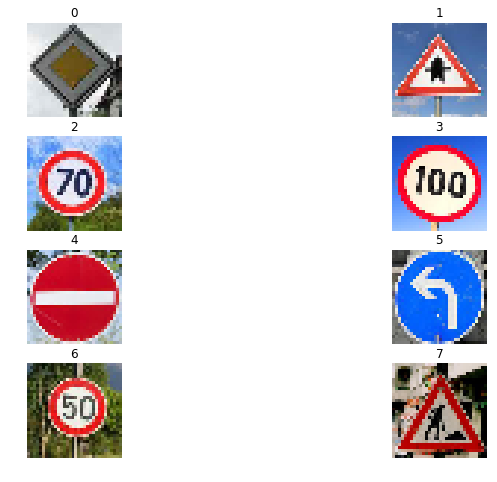

In [17]:
### Load the images and plot them here.
### Feel free to use as many code cells as needed.
#Load test images from internet and display
#Import test images 
import glob
import numpy as np
import cv2

test_img_paths = [img_path for img_path in glob.glob("./test_images/*")]
test_img=np.uint8(np.zeros((8,32,32,3)))
for i, imp in enumerate(test_img_paths):
    img=cv2.imread(imp, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (32,32))
    b,g,r = cv2.split(img)
    img = cv2.merge([r,g,b])
    #plt.imshow(img)
    test_img[i]=img
print(test_img[4].shape)

#Visualize new raw images
plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(4, 2, i+1)
    plt.imshow(test_img[i]) 
    plt.title(i)
    plt.axis('off')
    num_of_samples.append(len(x_selected))
plt.show()

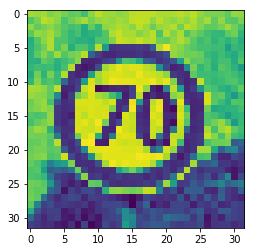

In [19]:
#Preprocess test images
#Convert to gray scale

test_img_gray = np.zeros((8, 32, 32, 1), dtype=np.float32)
for i, element in enumerate(test_img):
    test_img_gray[i] = gray_image(element)
    
plt.imshow(test_img_gray[2].reshape(32,32))

#Normalize the images
test_img_gray = (test_img_gray/255)

### Predict the Sign Type for Each Image

In [20]:
### Run the predictions here and use the model to output the prediction for each image.
### Make sure to pre-process the images with the same pre-processing pipeline used earlier.
### Feel free to use as many code cells as needed.
def test_net(test_data, sess):
    pred_sign = sess.run(tf.argmax(logits, 1), feed_dict={x: test_data, keep_prob: 1.0})
    return pred_sign

with tf.Session() as sess:
    saver.restore(sess, tf.train.latest_checkpoint('.'))
    signs_classes=test_net(test_img_gray, sess)
    

### Analyze Performance

In [21]:
### Calculate the accuracy for these 5 new images. 
### For example, if the model predicted 1 out of 5 signs correctly, it's 20% accurate on these new images.
print(signs_classes)

[12 11  4 32 17 12  2 25]


######    As seen in the resulting classification above, the model predicted 6 out of 8 images properly leading to 75% accuracy that is comaparable to test and validation accuracy of 92% and 96% respectively.

4th test image of 100kmph sign and 6th image(left ahead) is classified wrongly with different classification each time the prediction is run. This indicates that there must something related to the image characteristics that might be different from training images as well as other test images.

Also, the label(32) that is predicted for incorrectly classified image, has only 210 examples which might also be the reason for incorrect classification.



### Output Top 5 Softmax Probabilities For Each Image Found on the Web

For each of the new images, print out the model's softmax probabilities to show the **certainty** of the model's predictions (limit the output to the top 5 probabilities for each image). [`tf.nn.top_k`](https://www.tensorflow.org/versions/r0.12/api_docs/python/nn.html#top_k) could prove helpful here. 

The example below demonstrates how tf.nn.top_k can be used to find the top k predictions for each image.

`tf.nn.top_k` will return the values and indices (class ids) of the top k predictions. So if k=3, for each sign, it'll return the 3 largest probabilities (out of a possible 43) and the correspoding class ids.

Take this numpy array as an example. The values in the array represent predictions. The array contains softmax probabilities for five candidate images with six possible classes. `tf.nn.top_k` is used to choose the three classes with the highest probability:

```
# (5, 6) array
a = np.array([[ 0.24879643,  0.07032244,  0.12641572,  0.34763842,  0.07893497,
         0.12789202],
       [ 0.28086119,  0.27569815,  0.08594638,  0.0178669 ,  0.18063401,
         0.15899337],
       [ 0.26076848,  0.23664738,  0.08020603,  0.07001922,  0.1134371 ,
         0.23892179],
       [ 0.11943333,  0.29198961,  0.02605103,  0.26234032,  0.1351348 ,
         0.16505091],
       [ 0.09561176,  0.34396535,  0.0643941 ,  0.16240774,  0.24206137,
         0.09155967]])
```

Running it through `sess.run(tf.nn.top_k(tf.constant(a), k=3))` produces:

```
TopKV2(values=array([[ 0.34763842,  0.24879643,  0.12789202],
       [ 0.28086119,  0.27569815,  0.18063401],
       [ 0.26076848,  0.23892179,  0.23664738],
       [ 0.29198961,  0.26234032,  0.16505091],
       [ 0.34396535,  0.24206137,  0.16240774]]), indices=array([[3, 0, 5],
       [0, 1, 4],
       [0, 5, 1],
       [1, 3, 5],
       [1, 4, 3]], dtype=int32))
```

Looking just at the first row we get `[ 0.34763842,  0.24879643,  0.12789202]`, you can confirm these are the 3 largest probabilities in `a`. You'll also notice `[3, 0, 5]` are the corresponding indices.

In [22]:
### Print out the top five softmax probabilities for the predictions on the German traffic sign images found on the web. 
### Feel free to use as many code cells as needed.

def test_net(test_data, sess): 
    prob = sess.run(tf.nn.softmax(logits), feed_dict={x: test_data, keep_prob: 1.0})    
    top_prob = tf.nn.top_k(prob, k=5)
    return sess.run(top_prob)


with tf.Session() as sess:
    saver.restore(sess, tf.train.latest_checkpoint('.'))
    signs_top_5=test_net(test_img_gray, sess)
    

In [23]:
print(signs_top_5)

TopKV2(values=array([[  9.99999642e-01,   3.40539771e-07,   3.52024594e-12,
          2.26637827e-12,   2.34818251e-14],
       [  1.00000000e+00,   1.02594868e-11,   3.79395625e-13,
          3.30252522e-14,   9.70449370e-18],
       [  1.00000000e+00,   5.54012081e-09,   2.70248646e-09,
          2.35133202e-12,   3.11318489e-16],
       [  6.79876149e-01,   2.84298122e-01,   2.98252944e-02,
          5.21258172e-03,   4.41495737e-04],
       [  1.00000000e+00,   3.01454758e-17,   3.78462143e-19,
          2.49653303e-20,   1.26196144e-20],
       [  4.38273847e-01,   2.86366761e-01,   1.29114285e-01,
          5.23272976e-02,   2.59440541e-02],
       [  1.00000000e+00,   1.53245061e-08,   7.74612552e-09,
          1.00136344e-10,   1.49884825e-12],
       [  8.93358052e-01,   5.78517653e-02,   2.36023683e-02,
          2.09930856e-02,   3.30087449e-03]], dtype=float32), indices=array([[12, 40, 42,  7,  1],
       [11, 21, 30, 31, 40],
       [ 4,  1,  0,  2,  5],
       [32, 41,  9

# Softmax probabilities

Looking at top 5 softmax probabilities(over 99%) of classfication for each image correctly classified, it seems that the model is very confident of its predictions. For the incorrect classfied images, top most softmax probability is lower at 67% and 43%.

### Project Writeup

Once you have completed the code implementation, document your results in a project writeup using this [template](https://github.com/udacity/CarND-Traffic-Sign-Classifier-Project/blob/master/writeup_template.md) as a guide. The writeup can be in a markdown or pdf file. 

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  \n",
    "**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.

---

## Step 4 (Optional): Visualize the Neural Network's State with Test Images

 This Section is not required to complete but acts as an additional excersise for understaning the output of a neural network's weights. While neural networks can be a great learning device they are often referred to as a black box. We can understand what the weights of a neural network look like better by plotting their feature maps. After successfully training your neural network you can see what it's feature maps look like by plotting the output of the network's weight layers in response to a test stimuli image. From these plotted feature maps, it's possible to see what characteristics of an image the network finds interesting. For a sign, maybe the inner network feature maps react with high activation to the sign's boundary outline or to the contrast in the sign's painted symbol.

 Provided for you below is the function code that allows you to get the visualization output of any tensorflow weight layer you want. The inputs to the function should be a stimuli image, one used during training or a new one you provided, and then the tensorflow variable name that represents the layer's state during the training process, for instance if you wanted to see what the [LeNet lab's](https://classroom.udacity.com/nanodegrees/nd013/parts/fbf77062-5703-404e-b60c-95b78b2f3f9e/modules/6df7ae49-c61c-4bb2-a23e-6527e69209ec/lessons/601ae704-1035-4287-8b11-e2c2716217ad/concepts/d4aca031-508f-4e0b-b493-e7b706120f81) feature maps looked like for it's second convolutional layer you could enter conv2 as the tf_activation variable.

For an example of what feature map outputs look like, check out NVIDIA's results in their paper [End-to-End Deep Learning for Self-Driving Cars](https://devblogs.nvidia.com/parallelforall/deep-learning-self-driving-cars/) in the section Visualization of internal CNN State. NVIDIA was able to show that their network's inner weights had high activations to road boundary lines by comparing feature maps from an image with a clear path to one without. Try experimenting with a similar test to show that your trained network's weights are looking for interesting features, whether it's looking at differences in feature maps from images with or without a sign, or even what feature maps look like in a trained network vs a completely untrained one on the same sign image.

<figure>
 <img src="visualize_cnn.png" width="380" alt="Combined Image" />
 <figcaption>
 <p></p> 
 <p style="text-align: center;"> Your output should look something like this (above)</p> 
 </figcaption>
</figure>
 <p></p> 


In [ ]:
### Visualize your network's feature maps here.
### Feel free to use as many code cells as needed.

# image_input: the test image being fed into the network to produce the feature maps
# tf_activation: should be a tf variable name used during your training procedure that represents the calculated state of a specific weight layer
# activation_min/max: can be used to view the activation contrast in more detail, by default matplot sets min and max to the actual min and max values of the output
# plt_num: used to plot out multiple different weight feature map sets on the same block, just extend the plt number for each new feature map entry

def outputFeatureMap(image_input, tf_activation, activation_min=-1, activation_max=-1 ,plt_num=1):
    # Here make sure to preprocess your image_input in a way your network expects
    # with size, normalization, ect if needed
    # image_input =
    # Note: x should be the same name as your network's tensorflow data placeholder variable
    # If you get an error tf_activation is not defined it may be having trouble accessing the variable from inside a function
    activation = tf_activation.eval(session=sess,feed_dict={x : image_input})
    featuremaps = activation.shape[3]
    plt.figure(plt_num, figsize=(15,15))
    for featuremap in range(featuremaps):
        plt.subplot(6,8, featuremap+1) # sets the number of feature maps to show on each row and column
        plt.title('FeatureMap ' + str(featuremap)) # displays the feature map number
        if activation_min != -1 & activation_max != -1:
            plt.imshow(activation[0,:,:, featuremap], interpolation="nearest", vmin =activation_min, vmax=activation_max, cmap="gray")
        elif activation_max != -1:
            plt.imshow(activation[0,:,:, featuremap], interpolation="nearest", vmax=activation_max, cmap="gray")
        elif activation_min !=-1:
            plt.imshow(activation[0,:,:, featuremap], interpolation="nearest", vmin=activation_min, cmap="gray")
        else:
            plt.imshow(activation[0,:,:, featuremap], interpolation="nearest", cmap="gray")